# Project Additional Materials — Daily AutoML Test Results

- Student ID: 10841269  
- Course Code: DATA70132  
- Academic Year: 2024–25  

**Environment:** See `README` and `ERP_Environment_2025.yaml`.  
**Reproduction:** Run this notebook top to bottom in the same folder as the trained model files (`automl_training_daily.pkl`, `xgb_daily.pkl`, `rf_daily.pkl`, `lgb_daily.pkl`) and `All_UKonly_daily_cleaned_ymd.nc`.  

This notebook loads trained AutoML models and reports daily test results (metrics and maps).


## Step 0 — Import required libraries


In [1]:
import pandas as pd
import numpy as np
import pickle
import xarray as xr
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature
warnings.filterwarnings("ignore")

## Step 1 — Load daily dataset & define test windows


In [ ]:
# Load the dataset
ds = xr.open_dataset("All_UKonly_daily_cleaned_ymd.nc", decode_times=False)
df = ds.to_dataframe().dropna().reset_index()

# Time split
df_test1 = df[(df["year"] >= 2021) & (df["year"] <= 2030)]
df_test2 = df[(df["year"] >= 2021) & (df["year"] <= 2021)]
df_test3  = df[(df["year"] >= 2021) & (df["year"] <= 2022)]
df_test4  = df[(df["year"] >= 2069) & (df["year"] <= 2069)]
df_test5  = df[(df["year"] >= 2069) & (df["year"] <= 2070)]
df_test6  = df[(df["year"] >= 2031) & (df["year"] <= 2080)]
df_test7  = df[(df["year"] >= 2021) & (df["year"] <= 2080)]

# Define features and target
features = ["TREFHT", "FLNS", "FSNS", "QBOT", "UBOT", "VBOT", "PRECT", "PRSN"]
target = "TREFMXAV_U"

# Prepare feature and target arrays
X_test1, y_test1 = df_test1[features], df_test1[target]
X_test2, y_test2 = df_test2[features], df_test2[target]
X_test3, y_test3 = df_test3[features], df_test3[target]
X_test4, y_test4 = df_test4[features], df_test4[target]
X_test5, y_test5 = df_test5[features], df_test5[target]
X_test6, y_test6 = df_test6[features], df_test6[target]
X_test7, y_test7 = df_test7[features], df_test7[target]

# Evaluate the model
def evaluate(model_path,X, y, label):
    # Load the pre-trained AutoML model
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    preds = model.predict(X)
    rmse = mean_squared_error(y, preds, squared=False)
    r2 = r2_score(y, preds)

    # Print evaluation results
    print(f"{label} - R²: {r2:.4f}, RMSE: {rmse:.4f}")

    return ( r2, rmse)

# Plotting functions
def plot_time_series_daily(model_path, X, y, df_test, label, smooth=None):
    # predict
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    preds = model.predict(X)

    # Build results with a proper date index
    res = df_test[["year","month","day","lat","lon","sim"]].copy()
    res["date"] = pd.to_datetime(dict(year=res["year"], month=res["month"], day=res["day"]))
    res["t"] = y.values
    res["p"] = preds

    # Space average within (date, sim), then ensemble mean across sim
    ts_true = res.groupby(["date","sim"])["t"].mean().groupby("date").mean()
    ts_pred = res.groupby(["date","sim"])["p"].mean().groupby("date").mean()

    # Optional smoothing for nicer plots
    if smooth:
        ts_true = ts_true.rolling(smooth, min_periods=1).mean()
        ts_pred = ts_pred.rolling(smooth, min_periods=1).mean()

    # Plot
    plt.figure(figsize=(12,5))
    plt.plot(ts_true.index, ts_true.values, label="True", color="black")
    plt.plot(ts_pred.index, ts_pred.values, label="Predicted", color="red", linestyle="--")
    plt.title(f"Daily Time Series — {label}")
    plt.xlabel("Date")
    plt.ylabel("Temperature")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Map plotting function
def plot_map(model_path, X, y, df_test, label,
             kind="residual",                      # "true" | "pred" | "residual" | "rmse"
             extent_uk=[-8, 2.5, 49.5, 60],        # lon_min, lon_max, lat_min, lat_max
             vmin=None, vmax=None):                # optional, to match color ranges across plots
    # predict
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    preds = model.predict(X)

    # assemble with sim id
    r = df_test[["lat","lon","sim"]].copy()
    r["t"] = y.values
    r["p"] = preds

    # compute ensemble-mean fields
    if kind == "true":
        s = r.groupby(["lat","lon","sim"])["t"].mean().groupby(["lat","lon"]).mean()
        title, cmap = f"Ensemble Mean True — {label}", "viridis"
    elif kind == "pred":
        s = r.groupby(["lat","lon","sim"])["p"].mean().groupby(["lat","lon"]).mean()
        title, cmap = f"Ensemble Mean Pred — {label}", "viridis"
    elif kind == "residual":
        s = (r["p"] - r["t"]).groupby([r["lat"], r["lon"], r["sim"]]).mean().groupby(["lat","lon"]).mean()
        title, cmap = f"Ensemble Mean Residual — {label}", "coolwarm"
    elif kind == "rmse":
        rmse = r.groupby(["lat","lon","sim"]).apply(lambda g: np.sqrt(np.mean((g["p"]-g["t"])**2)))
        s = rmse.groupby(["lat","lon"]).mean()
        title, cmap = f"Ensemble Mean RMSE — {label}", "Reds"
    else:
        raise ValueError("kind must be 'true'|'pred'|'residual'|'rmse'")

    # 2D grid
    grid = s.unstack().sort_index(axis=0).sort_index(axis=1)
    lats, lons, data = grid.index.values, grid.columns.values, grid.values

    # plot
    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={"projection": ccrs.PlateCarree()}, layout="constrained")
    im = ax.pcolormesh(lons, lats, data, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)
    ax.set_extent(extent_uk, crs=ccrs.PlateCarree())
    ax.coastlines("10m"); ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

    gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                      linewidth=0.3, color="gray", alpha=0.5)
    gl.right_labels = False
    gl.top_labels = False

    fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.9, pad=0.06)
    ax.set_title(title); plt.show()

# RMSE grid calculation function
def rmse_grid(model_path, X, y, df_test):
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    p = model.predict(X)
    r = df_test[["lat","lon","sim"]].copy()
    r["t"] = y.values; r["p"] = p
    rmse = r.groupby(["lat","lon","sim"]).apply(
        lambda g: np.sqrt(np.mean((g["p"]-g["t"])**2))
    ).groupby(["lat","lon"]).mean().unstack().sort_index(axis=0).sort_index(axis=1)
    return rmse.values  # 2D array


## Step 2 — Evaluate Baseline AutoML model


In [ ]:
# Baseline model evaluation
evaluate("automl_training_daily.pkl", X_test1, y_test1, "LGBM_Daily_2021_2030_Baseline")
evaluate("automl_training_daily.pkl", X_test2, y_test2, "LGBM_Daily_2021_2021_Baseline")
evaluate("automl_training_daily.pkl", X_test3, y_test3, "LGBM_Daily_2021_2022_Baseline")
evaluate("automl_training_daily.pkl", X_test4, y_test4, "LGBM_Daily_2069_2069_Baseline")
evaluate("automl_training_daily.pkl", X_test5, y_test5, "LGBM_Daily_2069_2070_Baseline")
evaluate("automl_training_daily.pkl", X_test6, y_test6, "LGBM_Daily_2031_2080_Baseline")
evaluate("automl_training_daily.pkl", X_test7, y_test7, "LGBM_Daily_2021_2080_Baseline")

LGBM_Daily_2021_2030_Baseline - R²: 0.9615, RMSE: 0.9653
LGBM_Daily_2021_2021_Baseline - R²: 0.9624, RMSE: 0.9562
LGBM_Daily_2021_2022_Baseline - R²: 0.9624, RMSE: 0.9629
LGBM_Daily_2069_2069_Baseline - R²: 0.9567, RMSE: 1.1055
LGBM_Daily_2069_2070_Baseline - R²: 0.9567, RMSE: 1.1170
LGBM_Daily_2031_2080_Baseline - R²: 0.9594, RMSE: 1.0563
LGBM_Daily_2021_2080_Baseline - R²: 0.9600, RMSE: 1.0417


(0.9600341723654026, 1.0416731847574934)

## Step 3 — Evaluate LGBM AutoML model


In [ ]:
# LightGBM model evaluation
evaluate("lgb_daily.pkl", X_test1, y_test1, "LGBM_Daily_2021_2030")
evaluate("lgb_daily.pkl", X_test2, y_test2, "LGBM_Daily_2021_2021")
evaluate("lgb_daily.pkl", X_test3, y_test3, "LGBM_Daily_2021_2022")
evaluate("lgb_daily.pkl", X_test4, y_test4, "LGBM_Daily_2069_2069")
evaluate("lgb_daily.pkl", X_test5, y_test5, "LGBM_Daily_2069_2070")
evaluate("lgb_daily.pkl", X_test6, y_test6, "LGBM_Daily_2031_2080")
evaluate("lgb_daily.pkl", X_test7, y_test7, "LGBM_Daily_2021_2080")

LGBM_Daily_2021_2030 - R²: 0.9637, RMSE: 0.9379
LGBM_Daily_2021_2021 - R²: 0.9645, RMSE: 0.9285
LGBM_Daily_2021_2022 - R²: 0.9646, RMSE: 0.9349
LGBM_Daily_2069_2069 - R²: 0.9578, RMSE: 1.0907
LGBM_Daily_2069_2070 - R²: 0.9578, RMSE: 1.1031
LGBM_Daily_2031_2080 - R²: 0.9608, RMSE: 1.0384
LGBM_Daily_2021_2080 - R²: 0.9615, RMSE: 1.0224


(0.9615023984817138, 1.0223601556663127)

## Step 4 — Evaluate Random Forest AutoML model


In [3]:
# Random Forest model evaluation
evaluate("rf_daily.pkl", X_test1, y_test1, "RF_Daily_2021_2030")
evaluate("rf_daily.pkl", X_test2, y_test2, "RF_Daily_2031_2080")
evaluate("rf_daily.pkl", X_test3, y_test3, "RF_Daily_2021_2022")
evaluate("rf_daily.pkl", X_test4, y_test4, "RF_Daily_2069_2069")
evaluate("rf_daily.pkl", X_test5, y_test5, "RF_Daily_2069_2070")
evaluate("rf_daily.pkl", X_test6, y_test6, "RF_Daily_2031_2080")
evaluate("rf_daily.pkl", X_test7, y_test7, "RF_Daily_2021_2080")

RF_Daily_2021_2030 - R²: 0.9520, RMSE: 1.0780
RF_Daily_2031_2080 - R²: 0.9531, RMSE: 1.0675
RF_Daily_2021_2022 - R²: 0.9531, RMSE: 1.0759
RF_Daily_2069_2069 - R²: 0.9505, RMSE: 1.1815
RF_Daily_2069_2070 - R²: 0.9502, RMSE: 1.1982
RF_Daily_2031_2080 - R²: 0.9518, RMSE: 1.1518
RF_Daily_2021_2080 - R²: 0.9521, RMSE: 1.1398


(0.9521476453501555, 1.139826462314746)

## Step 5 — Evaluate XGBoost AutoML model


In [ ]:
# Random Forest model evaluation
evaluate("xgb_daily.pkl", X_test1, y_test1, "xgb_Daily_2021_2030")
evaluate("xgb_daily.pkl", X_test2, y_test2, "xgb_Daily_2031_2080")
evaluate("xgb_daily.pkl", X_test3, y_test3, "XGB_Daily_2021_2022")
evaluate("xgb_daily.pkl", X_test4, y_test4, "XGB_Daily_2069_2069")
evaluate("xgb_daily.pkl", X_test5, y_test5, "XGB_Daily_2069_2070")
evaluate("xgb_daily.pkl", X_test6, y_test6, "XGB_Daily_2031_2080")
evaluate("xgb_daily.pkl", X_test7, y_test7, "XGB_Daily_2021_2080")

xgb_Daily_2021_2030 - R²: 0.9617, RMSE: 0.9631
xgb_Daily_2031_2080 - R²: 0.9626, RMSE: 0.9539
XGB_Daily_2021_2022 - R²: 0.9626, RMSE: 0.9611
XGB_Daily_2069_2069 - R²: 0.9569, RMSE: 1.1025
XGB_Daily_2069_2070 - R²: 0.9569, RMSE: 1.1139
XGB_Daily_2031_2080 - R²: 0.9596, RMSE: 1.0535
XGB_Daily_2021_2080 - R²: 0.9602, RMSE: 1.0390


(0.9602418736667112, 1.038963)

## Step 6 — RMSE maps for selected periods (LGBM, best-performing model)


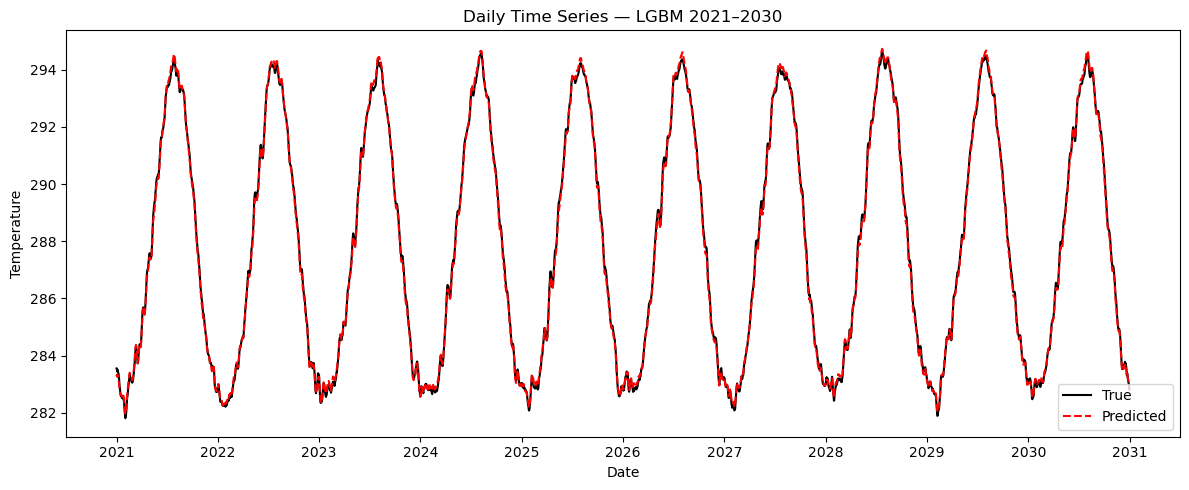

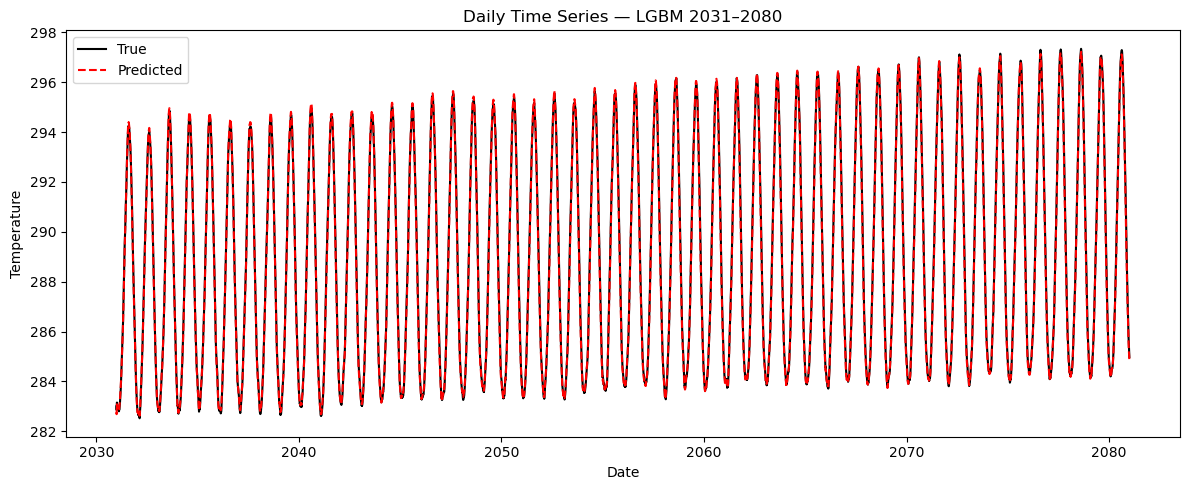

In [ ]:
# 2021–2030 daily
plot_time_series_daily("lgb_daily.pkl", X_test1, y_test1, df_test1, "LGBM 2021–2030", smooth="7D")
# 2031–2080 daily
plot_time_series_daily("lgb_daily.pkl", X_test6, y_test6, df_test6, "LGBM 2031–2080", smooth="30D")

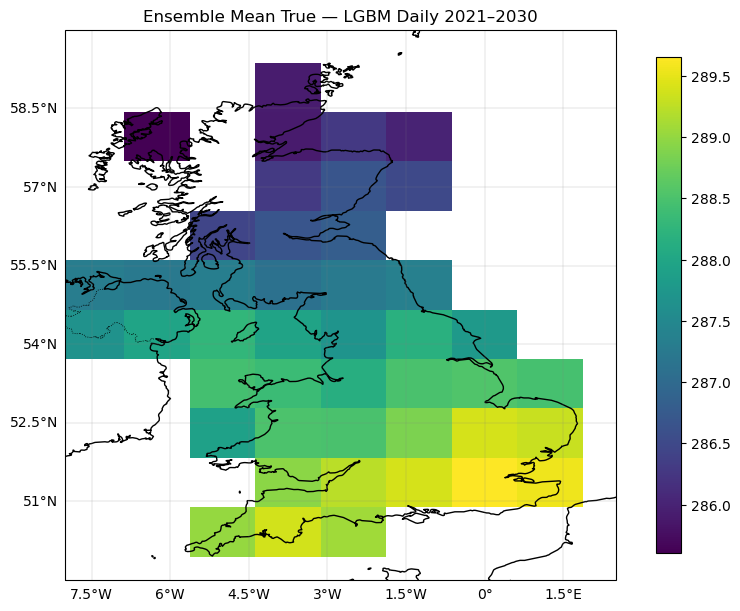

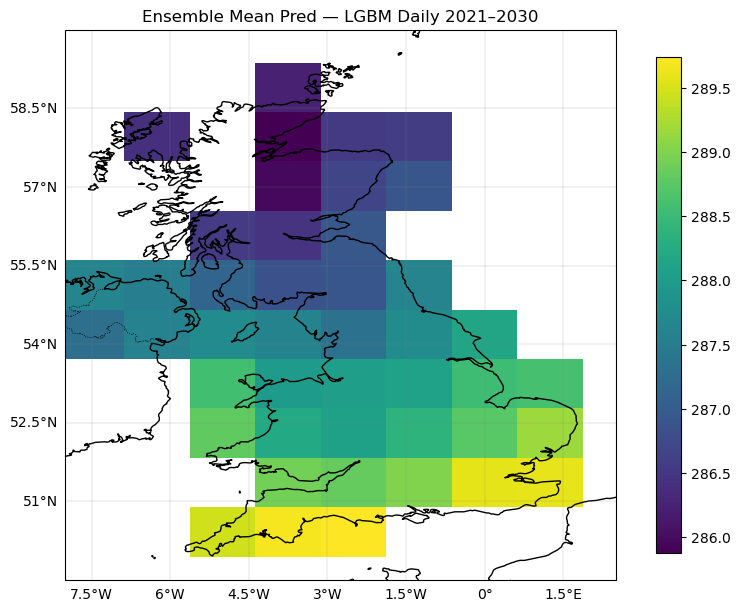

In [ ]:
# Trure map 
plot_map("lgb_daily.pkl", X_test1, y_test1, df_test1, "LGBM Daily 2021–2030", kind="true")
# Prediction map 
plot_map("lgb_daily.pkl", X_test1, y_test1, df_test1, "LGBM Daily 2021–2030", kind="pred")

RMSE color scale: 0.75 1.3795109832718202


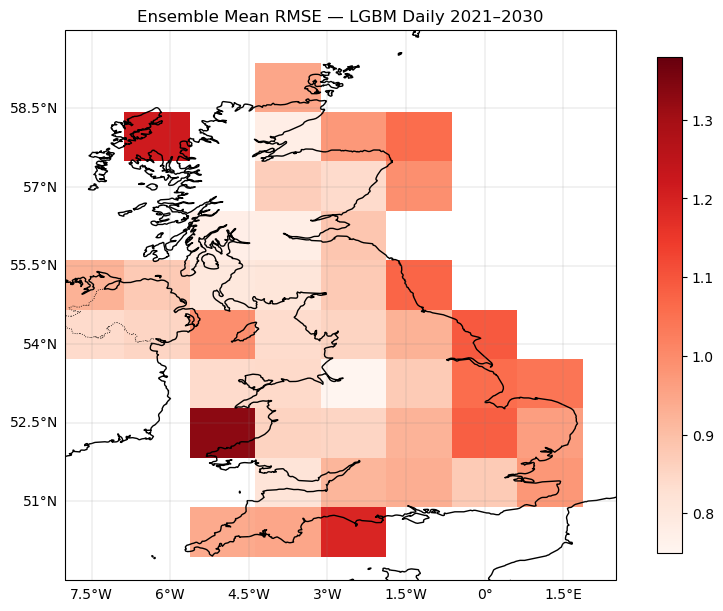

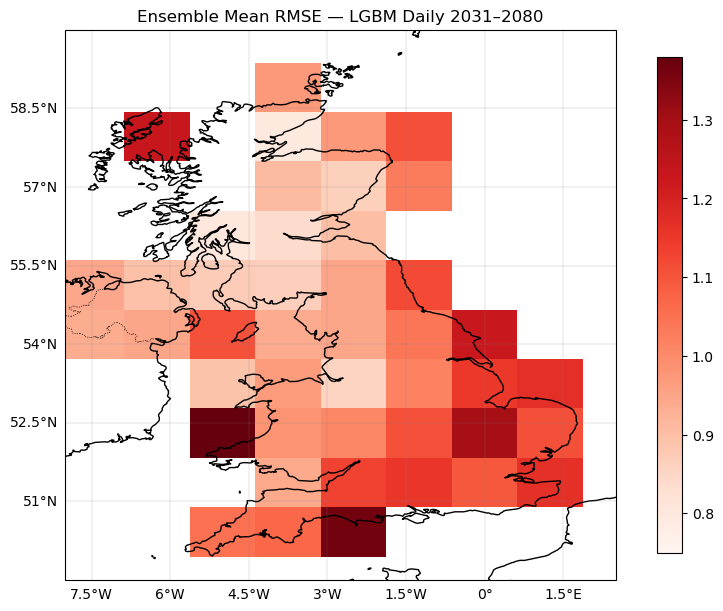

In [ ]:
# Calculate RMSE grids for two time periods
G1 = rmse_grid("lgb_daily.pkl", X_test1, y_test1, df_test1)  # 2021–2030
G2 = rmse_grid("lgb_daily.pkl", X_test6, y_test6, df_test6)  # 2031–2080

# 2) Determine vmin/vmax for color scale
vmin = 0.75
vmax = max(np.nanquantile(G1, 0.98), np.nanquantile(G2, 0.98)) # 98th percentile for better visualisation

print("RMSE color scale:", vmin, vmax)

# Plot
plot_map("lgb_daily.pkl", X_test1, y_test1, df_test1,
         "LGBM Daily 2021–2030", kind="rmse", vmin=vmin, vmax=vmax)

plot_map("lgb_daily.pkl", X_test6, y_test6, df_test6,
         "LGBM Daily 2031–2080", kind="rmse", vmin=vmin, vmax=vmax)

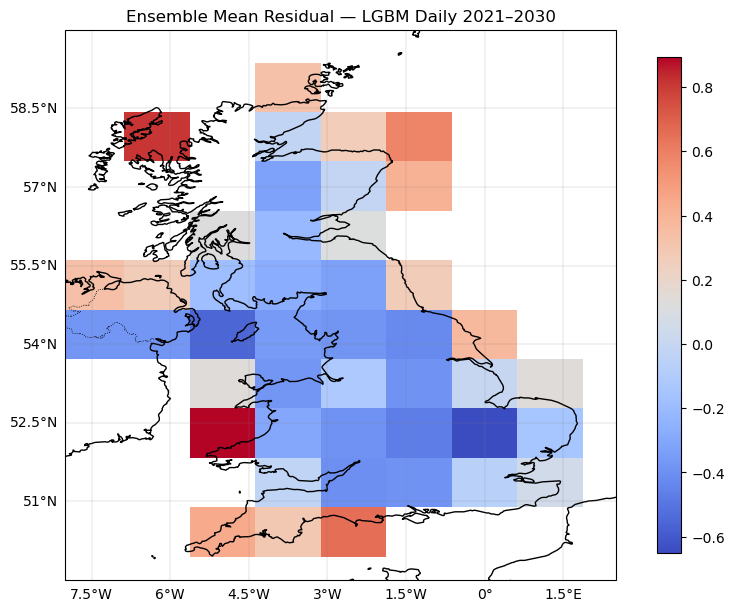

In [ ]:
# Residual map
plot_map("lgb_daily.pkl", X_test1, y_test1, df_test1, "LGBM Daily 2021–2030", kind="residual")

## Step 7 — Feature importance (Random Forest)


In [ ]:
# Feature importance
with open("rf_daily.pkl","rb") as f:
    rf = pickle.load(f) 

names = rf.feature_names_in_ 
imp   = rf.feature_importances_.astype(float)

df = (pd.DataFrame({"feature": names, "gini": imp, "gini_%": imp/imp.sum()*100})
        .sort_values("gini", ascending=False).reset_index(drop=True))
print("Feature importance (daily):")
print(df.to_string(index=False))


Feature importance (daily):
feature     gini    gini_%
 TREFHT 0.354737 35.473669
   QBOT 0.229459 22.945880
   FSNS 0.185799 18.579939
   PRSN 0.154074 15.407446
   VBOT 0.021333  2.133295
   FLNS 0.020910  2.090990
  PRECT 0.018188  1.818754
   UBOT 0.015500  1.550027
